## PART1

In [2]:
import pandas as pd
import numpy as np 
import  matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn import metrics

df = pd.read_csv('clean_data.csv')
display(df.head())

display(df.shape)





,id,screen_name,location,description,url,followers_count,friends_count,listed_count,created_at,favourites_count,verified,statuses_count,lang,status,default_profile,default_profile_image,name,bot
0,8.160000e+17,"""HoustonPokeMap""","""Houston, TX""","""Rare and strong PokŽmon in Houston, TX. See m...","""https://t.co/dnWuDbFRkt""",1291,0,10,"""Mon Jan 02 02:25:26 +0000 2017""",0,False,78554,"""en""","{\n ""created_at"": ""Sun Mar 12 15:44:04 +0...",True,False,"""Houston PokŽ Alert""",1
1,4.843621e+09,kernyeahx,"Templeville town, MD, USA",From late 2014 Socium Marketplace will make sh...,NaN,1,349,0,2/1/2016 7:37,38,False,31,en,NaN,True,False,Keri Nelson,1
2,4.303727e+09,mattlieberisbot,NaN,"Inspired by the smart, funny folks at @replyal...",https://t.co/P1e1o0m4KC,1086,0,14,Fri Nov 20 18:53:22 +0000 2015,0,False,713,en,"{'retweeted': False, 'is_quote_status': False,...",True,False,Matt Lieber Is Bot,1
3,3.063139e+09,sc_papers,NaN,NaN,NaN,33,0,8,2/25/2015 20:11,0,False,676,en,Construction of human anti-tetanus single-chai...,True,True,single cell papers,1
4,2.955142e+09,lucarivera16,"Dublin, United States",Inspiring cooks everywhere since 1956.,NaN,11,745,0,1/1/2015 17:44,146,False,185,en,NaN,False,False,lucarivera16,1


(2672, 18)

In [3]:
display(df.columns)
missingCount = df.isnull().sum()
display(missingCount)

threshold = 0.35* len(df)
df = df.dropna(thresh=len(df) - threshold, axis=1)

display(df.shape)
display(df.head(5))

##need to delete url 
## need to delete location 


Index(['id', 'screen_name', 'location', 'description', 'url',
       'followers_count', 'friends_count', 'listed_count', 'created_at',
       'favourites_count', 'verified', 'statuses_count', 'lang', 'status',
       'default_profile', 'default_profile_image', 'name', 'bot'],
      dtype='object')

id                          0
screen_name                 0
location                  963
description               387
url                      1347
followers_count             0
friends_count               0
listed_count                0
created_at                  0
favourites_count            0
verified                    0
statuses_count              0
lang                        0
status                    325
default_profile             0
default_profile_image       0
name                        0
bot                         0
dtype: int64

(2672, 16)

,id,screen_name,description,followers_count,friends_count,listed_count,created_at,favourites_count,verified,statuses_count,lang,status,default_profile,default_profile_image,name,bot
0,8.160000e+17,"""HoustonPokeMap""","""Rare and strong PokŽmon in Houston, TX. See m...",1291,0,10,"""Mon Jan 02 02:25:26 +0000 2017""",0,False,78554,"""en""","{\n ""created_at"": ""Sun Mar 12 15:44:04 +0...",True,False,"""Houston PokŽ Alert""",1
1,4.843621e+09,kernyeahx,From late 2014 Socium Marketplace will make sh...,1,349,0,2/1/2016 7:37,38,False,31,en,NaN,True,False,Keri Nelson,1
2,4.303727e+09,mattlieberisbot,"Inspired by the smart, funny folks at @replyal...",1086,0,14,Fri Nov 20 18:53:22 +0000 2015,0,False,713,en,"{'retweeted': False, 'is_quote_status': False,...",True,False,Matt Lieber Is Bot,1
3,3.063139e+09,sc_papers,NaN,33,0,8,2/25/2015 20:11,0,False,676,en,Construction of human anti-tetanus single-chai...,True,True,single cell papers,1
4,2.955142e+09,lucarivera16,Inspiring cooks everywhere since 1956.,11,745,0,1/1/2015 17:44,146,False,185,en,NaN,False,False,lucarivera16,1


In [4]:
df2 = df[['id', 'screen_name', 'description',
       'followers_count', 'friends_count', 'listed_count', 'created_at',
       'favourites_count', 'verified', 'statuses_count', 'lang', 'status',
       'default_profile', 'default_profile_image', 'name', 'bot']]


display(df2.head())


,id,screen_name,description,followers_count,friends_count,listed_count,created_at,favourites_count,verified,statuses_count,lang,status,default_profile,default_profile_image,name,bot
0,8.160000e+17,"""HoustonPokeMap""","""Rare and strong PokŽmon in Houston, TX. See m...",1291,0,10,"""Mon Jan 02 02:25:26 +0000 2017""",0,False,78554,"""en""","{\n ""created_at"": ""Sun Mar 12 15:44:04 +0...",True,False,"""Houston PokŽ Alert""",1
1,4.843621e+09,kernyeahx,From late 2014 Socium Marketplace will make sh...,1,349,0,2/1/2016 7:37,38,False,31,en,NaN,True,False,Keri Nelson,1
2,4.303727e+09,mattlieberisbot,"Inspired by the smart, funny folks at @replyal...",1086,0,14,Fri Nov 20 18:53:22 +0000 2015,0,False,713,en,"{'retweeted': False, 'is_quote_status': False,...",True,False,Matt Lieber Is Bot,1
3,3.063139e+09,sc_papers,NaN,33,0,8,2/25/2015 20:11,0,False,676,en,Construction of human anti-tetanus single-chai...,True,True,single cell papers,1
4,2.955142e+09,lucarivera16,Inspiring cooks everywhere since 1956.,11,745,0,1/1/2015 17:44,146,False,185,en,NaN,False,False,lucarivera16,1


In [5]:
bag_of_words = ["bot", "follow me", "free", "fake", "virus", "troll", "clone", "tweet me"]

def check_word(value):
    if pd.isna(value):
        return False
    for word in bag_of_words:
        if word in str(value).lower():
            return True
    return False

for col in ['screen_name', 'name', 'description', 'status']:
    df2[col + '_binary'] = df2[col].apply(check_word)

display(df2[['screen_name', 'screen_name_binary', 'name', 'name_binary']].head())

,screen_name,screen_name_binary,name,name_binary
0,"""HoustonPokeMap""",False,"""Houston PokŽ Alert""",False
1,kernyeahx,False,Keri Nelson,False
2,mattlieberisbot,True,Matt Lieber Is Bot,True
3,sc_papers,False,single cell papers,False
4,lucarivera16,False,lucarivera16,False


(0.0, 5000.0)

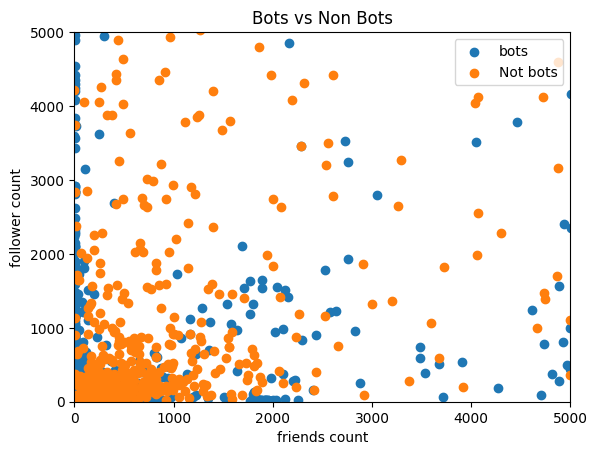

In [6]:


df_bots = df2[df2['bot']==1]
df_notBots = df2[df2['bot']==0]

plt.scatter(df_bots.friends_count, df_bots.followers_count, label="bots")
plt.scatter(df_notBots.friends_count, df_notBots.followers_count, label="Not bots")
plt.legend()
plt.title("Bots vs Non Bots")
plt.xlabel("friends count")
plt.ylabel("follower count")
plt.xlim(0,5000)
plt.ylim(0,5000)

In [7]:
bag_of_words = ["bot", "follow me", "free", "fake", "virus", "troll", "clone", "tweet me"]

colCheck = ['screen_name', 'name', 'description', 'status']

def check_word(value):
    if pd.isna(value):
        return False
    for word in bag_of_words:
        if word in str(value).lower():
            return True
    return False

for col in ['screen_name', 'name', 'description', 'status']:
    results = []
    for i in range(len(df)):
        results.append(check_word(df2[col][i]))
    df2[col + '_binary'] = results

In [8]:
df2.head()

,id,screen_name,description,followers_count,friends_count,listed_count,created_at,favourites_count,verified,statuses_count,lang,status,default_profile,default_profile_image,name,bot,screen_name_binary,name_binary,description_binary,status_binary
0,8.160000e+17,"""HoustonPokeMap""","""Rare and strong PokŽmon in Houston, TX. See m...",1291,0,10,"""Mon Jan 02 02:25:26 +0000 2017""",0,False,78554,"""en""","{\n ""created_at"": ""Sun Mar 12 15:44:04 +0...",True,False,"""Houston PokŽ Alert""",1,False,False,False,False
1,4.843621e+09,kernyeahx,From late 2014 Socium Marketplace will make sh...,1,349,0,2/1/2016 7:37,38,False,31,en,NaN,True,False,Keri Nelson,1,False,False,False,False
2,4.303727e+09,mattlieberisbot,"Inspired by the smart, funny folks at @replyal...",1086,0,14,Fri Nov 20 18:53:22 +0000 2015,0,False,713,en,"{'retweeted': False, 'is_quote_status': False,...",True,False,Matt Lieber Is Bot,1,True,True,True,True
3,3.063139e+09,sc_papers,NaN,33,0,8,2/25/2015 20:11,0,False,676,en,Construction of human anti-tetanus single-chai...,True,True,single cell papers,1,False,False,False,False
4,2.955142e+09,lucarivera16,Inspiring cooks everywhere since 1956.,11,745,0,1/1/2015 17:44,146,False,185,en,NaN,False,False,lucarivera16,1,False,False,False,False


In [16]:


X = df2[['followers_count', 'friends_count', 'screen_name_binary',
         'name_binary', 'status_binary', 'verified', 'statuses_count']]
         
Y = df2['bot']
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.3)
clf = DecisionTreeClassifier(criterion="entropy")

clf.fit(Xtrain, Ytrain)
Ypred = clf.predict(Xtrain)
Ypred_test = clf.predict(Xtest)
print("Training Accuracy:", metrics.accuracy_score(Ytrain, Ypred))
print("Testing Accuracy:", metrics.accuracy_score(Ytest, Ypred_test))
from sklearn.tree import export_text
print(export_text(clf, feature_names=list(X.columns)))



Training Accuracy: 0.9989304812834224
Testing Accuracy: 0.827930174563591
|--- verified <= 0.50
|   |--- friends_count <= 5.50
|   |   |--- statuses_count <= 30.00
|   |   |   |--- friends_count <= 4.50
|   |   |   |   |--- followers_count <= 23407.00
|   |   |   |   |   |--- friends_count <= 3.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- friends_count >  3.50
|   |   |   |   |   |   |--- statuses_count <= 2.00
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- statuses_count >  2.00
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- followers_count >  23407.00
|   |   |   |   |   |--- class: 0
|   |   |   |--- friends_count >  4.50
|   |   |   |   |--- class: 0
|   |   |--- statuses_count >  30.00
|   |   |   |--- followers_count <= 75777.50
|   |   |   |   |--- followers_count <= 239.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- followers_count >  239.50
|   |   |   |   |   |--- followers_count <= 241.00
|   |   |   |  

In [17]:
from sklearn.linear_model import LogisticRegression


X = df2[['followers_count', 'friends_count', 'screen_name_binary',
         'name_binary', 'status_binary', 'verified', 'statuses_count']]
         
Y = df2['bot']
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.3)
clf = LogisticRegression()

clf.fit(Xtrain, Ytrain)
Ypred = clf.predict(Xtrain)
Ypred_test = clf.predict(Xtest)
print("Training Accuracy:", metrics.accuracy_score(Ytrain, Ypred))
print("Testing Accuracy:", metrics.accuracy_score(Ytest, Ypred_test))



Training Accuracy: 0.6989304812834225
Testing Accuracy: 0.699501246882793


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [27]:


X = df2[['followers_count', 'friends_count', 'screen_name_binary',
         'name_binary', 'status_binary', 'verified', 'statuses_count']]
         
Y = df2['bot']
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.3)
clf = DecisionTreeClassifier(criterion="entropy", max_depth =2)

clf.fit(Xtrain, Ytrain)
Ypred = clf.predict(Xtrain)
Ypred_test = clf.predict(Xtest)
print("Training Accuracy:", metrics.accuracy_score(Ytrain, Ypred))
print("Testing Accuracy:", metrics.accuracy_score(Ytest, Ypred_test))
from sklearn.tree import export_text
print(export_text(clf, feature_names=list(X.columns)))

print("Training bot: ", len(Ytrain[Ytrain == 1]) / len(Ytrain) * 100)
print("Testing bot:", len(Ytest[Ytest == 1]) / len(Ytest) * 100)


Training Accuracy: 0.7844919786096257
Testing Accuracy: 0.7955112219451371
|--- verified <= 0.50
|   |--- friends_count <= 45.50
|   |   |--- class: 1
|   |--- friends_count >  45.50
|   |   |--- class: 0
|--- verified >  0.50
|   |--- friends_count <= 13387.50
|   |   |--- class: 0
|   |--- friends_count >  13387.50
|   |   |--- class: 0

Training bot:  46.57754010695187
Testing bot: 45.51122194513716


## Part 1 Short answer Question


1. When you zoom in on the scatter plot you can see that a lot of the bots with a lot of followers do not have friends or has very little friends, but of course there are also bots that have a lot of friends and followers, but the majority patter is that they have no friends

2. the training accuracy was 99%nd the testing accuracy is 83.5%

3. I think the decision tree is a better classifier for this specific isntance, because you can't really split up the bots and non bot accounts with a regression line, it's not a the closer you are the better data, this is a the account is a bot or it's not a bot 

4. IT classifies users by being verified or not and the amount for friends count, this tells us that the calssifiers think that an account being verifeid and also it's friends count is the most important feature to determine if someone is a bot or not

4c. they are very similar for the training percentage it is 46.256% and for the test percentage it is 46.259%

5. no because if you said no for every row you would still get 90% which is better than 85% 

6. if in the case where the 70% data you are training did not have the bots and all the bots ended up in the 30% test, then your model would have not trained on any information about bots, a better alternative is to make sure there are bots within the data you are training and also make sure they are in the testing part of the data set

7. test split, how much of the data are you going to train vs to test, visualization, through visualization you can determine which classifier model to use, also make sure to know how to clean the missing data, according to what you want to do and consider which columns are the most important.

## PART 2

In [11]:
import random

X1s = []
X2s = []
Ys = []

for i in range(1000):
    x1 = random.random()
    x2 = random.random()
    if x1 + x2 > 1:
        y =1
    else:
        y =0
    X1s.append(x1)
    X2s.append(x2)
    Ys.append(y)

df = pd.DataFrame(data={'X1':X1s,'X2':X2s,'Y':Ys})


In [12]:
df.head()

,X1,X2,Y
0,0.590627,0.582946,1
1,0.011288,0.859476,0
2,0.536946,0.155262,0
3,0.169975,0.640449,0
4,0.920306,0.584535,1


Text(0, 0.5, 'X2')

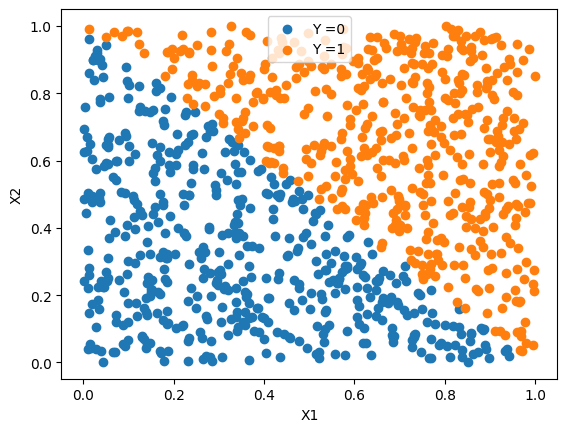

In [13]:
y1 = df[df['Y'] ==0 ]
y2 = df[df['Y'] ==1]

plt.scatter(y1['X1'],y1['X2'], label = 'Y =0')
plt.scatter(y2['X1'],y2['X2'], label = 'Y =1')
plt.legend()
plt.xlabel('X1')
plt.ylabel('X2')

In [14]:
X = df[['X1', 'X2']]
Y = df['Y']


clf = DecisionTreeClassifier(criterion='entropy', max_depth=2)
clf.fit(X, Y)
Ypred = clf.predict(X)
print("Decision Tree Accuracy:", metrics.accuracy_score(Y, Ypred))
print()


clf = LogisticRegression()
clf.fit(X, Y)
Ypred = clf.predict(X)
print("Logistic Regression Accuracy:", metrics.accuracy_score(Y, Ypred))

Decision Tree Accuracy: 0.834

Logistic Regression Accuracy: 0.996


## part 2 short answer question

1. we expect it to get 100% because through teh visualization you can clearly see that a diagonal line could seperate the different Y values

2. I got 88.1%

3. now the accuracry for both the decisions tree and logistic regression is 1 

4. it is because the machine basically can learn every path, which could make the machine just memorize the patterns instead of actually learning


In [15]:
X = df[['X1', 'X2']]
Y = df['Y']


clf = DecisionTreeClassifier(criterion='entropy')
clf.fit(X, Y)
Ypred = clf.predict(X)
print("Decision Tree Accuracy:", metrics.accuracy_score(Y, Ypred))
print()


clf = LogisticRegression()
clf.fit(X, Y)
Ypred = clf.predict(X)
print("Logistic Regression Accuracy:", metrics.accuracy_score(Y, Ypred))

Decision Tree Accuracy: 1.0

Logistic Regression Accuracy: 0.996
